**Introduction**  
This project features a custom K-Means clustering algorithm designed to extract numbers from Ishihara color blindness test images. The process involves:  
- **Custom K-Means**: Built from scratch with K-Means++ initialization for improved clustering accuracy.  
- **Image Processing**: Images are converted to LAB color space, with the 'a' channel normalized and clustered to isolate the number on a black background.  
- **Batch Processing**: Handles four images simultaneously, showing original and extracted results side-by-side.  
- **Detailed Output**: Displays a grid of results with clustering insights, including cluster centers, sizes, inertia, and iterations.  

This method effectively extracts numbers while offering a transparent view of the clustering process.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

<div style="font-size:12px; line-height:1.2;">

**KMeans Class Implementation Explained**

**1. Initialization (`__init__`)**  
- `n_clusters`: number of clusters to form  
- `init`: center initialization method (`'k-means++'` or `'random'`)  
- `n_init`: how many times to run the algorithm with different seeds  
- `max_iter`: maximum Lloyd iterations per run  
- `tol`: convergence tolerance (sum of squared center shifts)  
- `random_state`: RNG seed for reproducibility  

**2. k-means++ Seeding (`_kmeans_plusplus`)**  
- Pick the first center at random.  
- For each new center, compute squared distances from each point to its nearest existing center.  
- Sample the next center with probability ∝ distance² (promotes spread-out seeds).  

**3. Lloyd’s Iterations (`_lloyd_iter`)**  
- **Assignment step**: assign each point to its nearest center.  
- **Update step**: recompute each center as the mean of its assigned points.  
- If any cluster is empty, reassign its center to a random data point.  
- Compute the total center-shift; stop when ≤ `tol` or `max_iter` is reached.  
- Return final centers, labels, inertia (sum of squared distances), and iteration count.  

**4. Fitting (`fit`)**  
- Convert input to float64.  
- Repeat seeding + Lloyd for `n_init` restarts.  
- Keep the result with lowest inertia.  

**5. Prediction (`predict`)**  
- For new data, compute squared distances to each learned center and assign to the nearest.
</div>


In [2]:
class KMeans:
    def __init__(self, n_clusters=8, init='k-means++', n_init=10,
                 max_iter=300, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.init = init
        self.n_init = n_init
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = np.random.RandomState(random_state)
        self.cluster_centers_ = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = 0

    def _kmeans_plusplus(self, X):
        n_samples, n_features = X.shape
        centers = np.empty((self.n_clusters, n_features), dtype=X.dtype)
        center_id = self.random_state.choice(n_samples)
        centers[0] = X[center_id]
        distances = np.full(n_samples, np.inf)
        for c in range(1, self.n_clusters):
            distances = np.minimum(distances, np.sum((X - centers[c-1])**2, axis=1))
            probs = distances / np.sum(distances)
            centers[c] = X[self.random_state.choice(n_samples, p=probs)]
        return centers

    def _lloyd_iter(self, X, centers):
        for i in range(self.max_iter):
            distances = np.sum((X[:, None] - centers)**2, axis=2)
            labels = np.argmin(distances, axis=1)
            new_centers = np.empty_like(centers)
            for j in range(self.n_clusters):
                cluster_points = X[labels == j]
                if cluster_points.shape[0] > 0:
                    new_centers[j] = cluster_points.mean(axis=0)
                else:
                    new_centers[j] = X[self.random_state.choice(X.shape[0])]
            shift = np.sum((new_centers - centers)**2)
            if shift <= self.tol:
                break
            centers = new_centers
        final_distances = np.sum((X[:, None] - centers)**2, axis=2)
        labels = np.argmin(final_distances, axis=1)
        inertia = np.sum(final_distances[np.arange(len(final_distances)), labels])
        return centers, labels, inertia, i + 1

    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)
        best_inertia = np.inf
        for _ in range(self.n_init):
            if self.init == 'k-means++':
                centers = self._kmeans_plusplus(X)
            elif self.init == 'random':
                centers = X[self.random_state.choice(X.shape[0], self.n_clusters, False)]
            centers, labels, inertia, n_iter = self._lloyd_iter(X, centers)
            if inertia < best_inertia:
                self.cluster_centers_ = centers
                self.labels_ = labels
                self.inertia_ = inertia
                self.n_iter_ = n_iter
                best_inertia = inertia
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float64)
        distances = np.sum((X[:, None] - self.cluster_centers_)**2, axis=2)
        return np.argmin(distances, axis=1)

<div style="font-size:12px; line-height:1.2;">

**Ishihara Test Image Processing Pipeline**

**1. Image Loading & Color Conversion**  
- Read with OpenCV (`cv2.imread`) in BGR.  
- Convert to RGB (`cv2.cvtColor`) for display.  
- Convert to CIELAB (`cv2.COLOR_BGR2LAB`) for color-based segmentation.  

**2. ‘a’-Channel Extraction & Normalization**  
- Extract the green–red axis (`lab[:, :, 1]`).  
- Standardize to zero mean, unit variance:  
  ```python
  a = (a - a.mean()) / a.std()


In [3]:
def process_images(image_paths):
    fig, axes = plt.subplots(4, 2, figsize=(12, 16))
    fig.suptitle('Ishihara Test Image Processing Results', fontsize=16)

    for i, image_path in enumerate(image_paths):
        # Load image and convert to LAB color space
        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

        # Extract and normalize the 'a' channel
        a_channel = lab[:, :, 1].astype(np.float64)
        a_channel = (a_channel - a_channel.mean()) / a_channel.std()

        # Reshape for clustering
        X = a_channel.reshape(-1, 1)

        # Apply K-Means with 2 clusters
        kmeans = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
        kmeans.fit(X)
        labels = kmeans.predict(X).reshape(lab.shape[:2])

        # Identify the cluster representing the number (higher 'a' value in LAB space)
        number_cluster = np.argmax(kmeans.cluster_centers_)

        # Create a binary mask for the number cluster
        binary_mask = (labels == number_cluster).astype(np.uint8) * 255

        # Display original and extracted number
        axes[i, 0].imshow(image_rgb)
        axes[i, 0].set_title(f'Original Image {i+1}')
        axes[i, 0].axis('off')
        axes[i, 1].imshow(binary_mask, cmap='gray')
        axes[i, 1].set_title(f'Extracted Number {i+1}')
        axes[i, 1].axis('off')

        # Print clustering details
        print(f"\n--- Image {i+1} Details ---")
        print("Cluster Centers:", kmeans.cluster_centers_.flatten())
        print("Cluster Sizes:", [np.sum(labels == j) for j in range(2)])
        print(f"Inertia: {kmeans.inertia_:.2f}")
        print(f"Iterations: {kmeans.n_iter_}")

    plt.tight_layout()
    plt.show()

In [4]:
# Upload four images in Google Colab
uploaded = files.upload()
image_paths = list(uploaded.keys())[:]

Saving 74.jpg to 74.jpg
Saving 42.jpg to 42.jpg
Saving 12.jpg to 12.jpg
Saving 6.jpg to 6.jpg



--- Image 1 Details ---
Cluster Centers: [-0.39566949  1.49497317]
Cluster Sizes: [np.int64(71165), np.int64(18835)]
Inertia: 36763.63
Iterations: 4

--- Image 2 Details ---
Cluster Centers: [-0.18784658  3.75851012]
Cluster Sizes: [np.int64(85716), np.int64(4284)]
Inertia: 26457.91
Iterations: 6

--- Image 3 Details ---
Cluster Centers: [-0.20866997  3.33812843]
Cluster Sizes: [np.int64(84705), np.int64(5295)]
Inertia: 27308.96
Iterations: 2

--- Image 4 Details ---
Cluster Centers: [ 0.49615641 -1.53856867]
Cluster Sizes: [np.int64(68054), np.int64(21946)]
Inertia: 21296.64
Iterations: 5


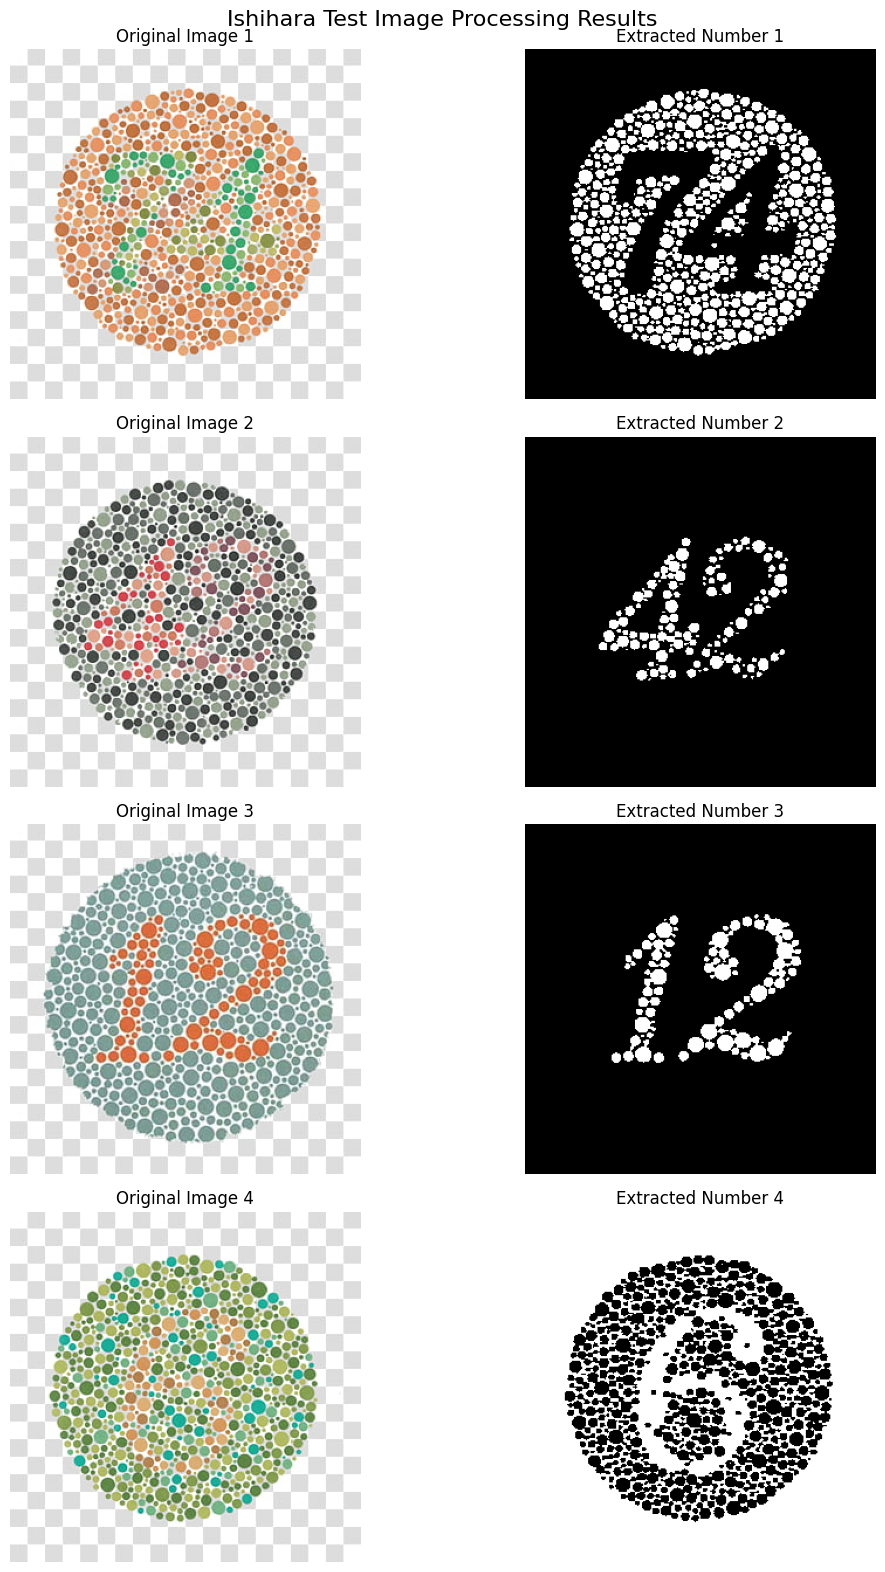

In [5]:
# Process and display results
process_images(image_paths)